# Financial Metrics Pipeline Analysis

This notebook demonstrates how the analytics layer of the Financial Metrics Pipeline can be used for quantitative market analysis.

The analysis is based on:

- Daily Returns
- Rolling Volatility
- Moving Averages
- Momentum

#### Dataset Requirements

This notebook assumes that the ETL pipeline has already been executed successfully and that the SQL Server contains market data for the **Magnificent 7 stocks covering Q1 and Q2 of 2026**. All visualizations and summary statistics are based on this dataset. If the underlying data is incomplete or unavailable, some analyses and figures may not produce meaningful results.

## 1. Import Libraries

The following libraries are required to connect to the SQL Server database, manipulate tabular data and visualise the calculated financial metrics.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from dotenv import load_dotenv
from IPython.display import display, Markdown

## 2. Load Configuration

The notebook loads the SQL Server configuration from the project's `.env` file. This ensures that sensitive information such as the SQL Server instance and database name are not hardcoded and remain consistent with the ETL pipeline.

In [2]:
load_dotenv()

SQL_SERVER = os.getenv("SQL_SERVER")
SQL_DATABASE = os.getenv("SQL_DATABASE")
SQL_DRIVER = os.getenv("SQL_DRIVER")

## 3. Connect to SQL Server

The notebook establishes a connection to the SQL Server database using the shared utility function from the project. Reusing the same connection logic as the ETL pipeline ensures consistency and avoids duplicated code.

In [3]:
from  python.utils.db import get_sql_connection

conn = get_sql_connection()

## 4. Load Analytics Data

The notebook loads the analytics views into individual pandas DataFrames. Keeping eacht dataset seperate improves readability and reflects the modular design of the SQL analytics layer.

In [4]:
daily_returns_query = """
    SELECT *
    FROM core.vw_daily_returns
    ORDER BY symbol, trade_date;
    """

daily_returns_df = pd.read_sql(daily_returns_query, conn)

log_returns_query = """
    SELECT *
    FROM core.vw_log_returns
    ORDER BY symbol, trade_date;
    """

log_returns_df = pd.read_sql(log_returns_query, conn)

rolling_volatitlity_query = """
    SELECT *
    FROM core.vw_rolling_volatility
    ORDER BY symbol, trade_date;
    """

rolling_volatility_df = pd.read_sql(rolling_volatitlity_query, conn)

moving_averages_query = """
    SELECT *
    FROM core.vw_moving_averages
    ORDER BY symbol, trade_date;
    """

moving_averages_df = pd.read_sql(moving_averages_query, conn)

momentum_query = """
    SELECT *
    FROM core.vw_momentum_signals
    ORDER BY symbol, trade_date;
    """

momentum_df = pd.read_sql(momentum_query, conn)

data_quality_query = """
    SELECT *
    FROM core.vw_data_quality
    ORDER BY symbol, trade_date;
    """

data_quality_df = pd.read_sql(data_quality_query, conn)

def percent_formatter(x, pos):
    return f"{x:.2%}"

C:\Users\Tom Höwing\AppData\Local\Temp\ipykernel_22828\2307524590.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  daily_returns_df = pd.read_sql(daily_returns_query, conn)
C:\Users\Tom Höwing\AppData\Local\Temp\ipykernel_22828\2307524590.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  log_returns_df = pd.read_sql(log_returns_query, conn)
C:\Users\Tom Höwing\AppData\Local\Temp\ipykernel_22828\2307524590.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rolling_volatility_df = pd.read_sql(rolling_volatitlity_query

## 5. Daily Returns Analysis

### Research Question

How do the daily returns of the selected  stocks evolve over time, and which stocks exhibit the strongest short-term fluctuations?

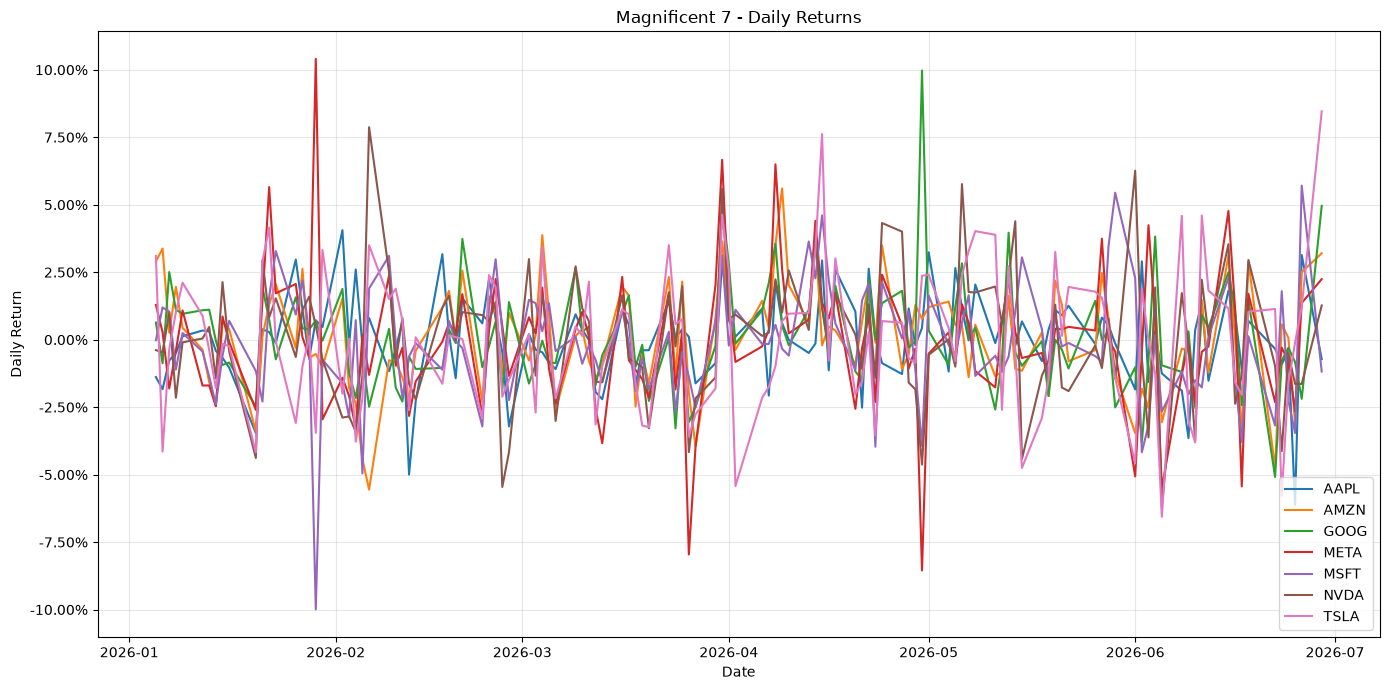

In [5]:
plt.figure(figsize=(14, 7))
for symbol, data in daily_returns_df.groupby("symbol"):
    plt.plot(data["trade_date"], data["daily_return"], label=symbol)

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

plt.title("Magnificent 7 - Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

While the plot provides an overview of the daily return series, the overlap between the seven stocks makes individual patterns difficult to distinguish. Therefore, additional visualizations are required to compare the return characteristics more effectively.

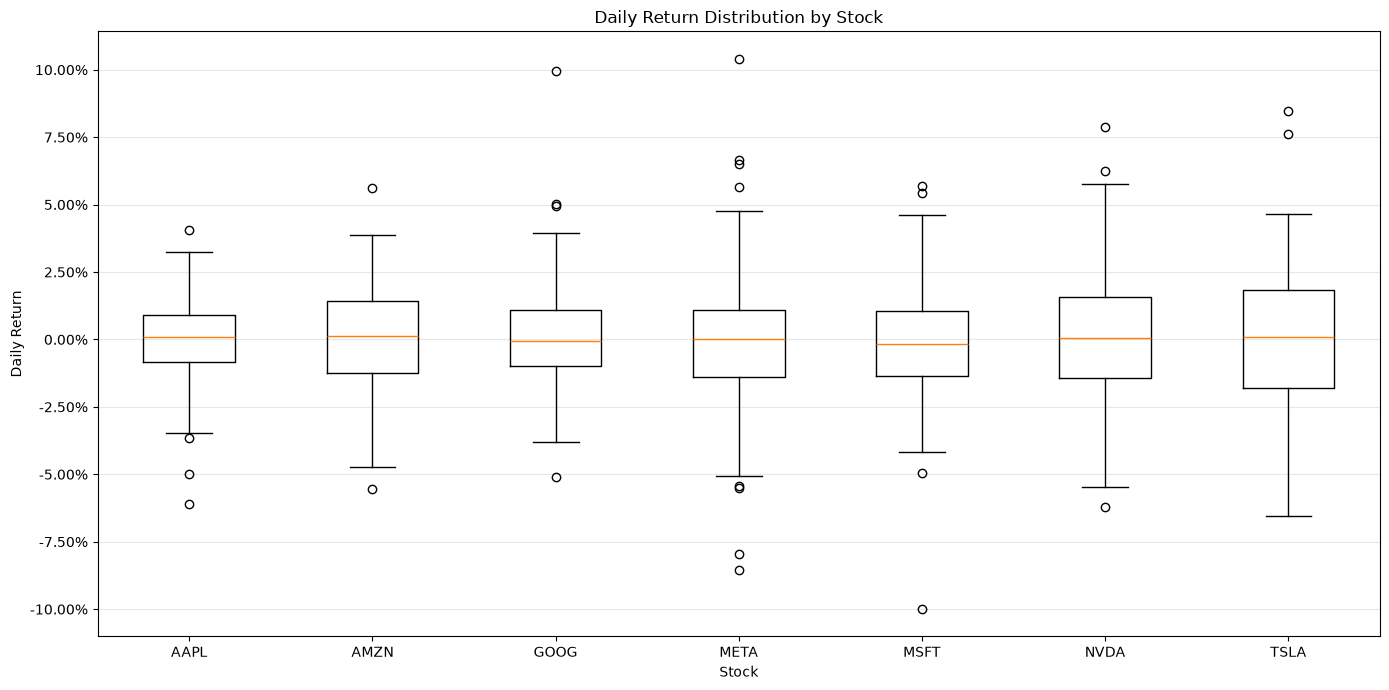

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,121.0,0.000469,0.016326,-0.061178,-0.008495,0.000952,0.009065,0.040581
AMZN,121.0,0.000684,0.020112,-0.055548,-0.012256,0.001342,0.014397,0.056045
GOOG,121.0,0.001096,0.019840,-0.050835,-0.009694,-0.000384,0.010907,0.099709
META,121.0,-0.000862,0.025488,-0.085500,-0.014070,0.000047,0.010835,0.104048
MSFT,121.0,-0.001790,0.021536,-0.099931,-0.013428,-0.001582,0.010428,0.057081
NVDA,121.0,0.000562,0.024149,-0.062014,-0.014123,0.000433,0.015913,0.078718
TSLA,121.0,-0.000161,0.026568,-0.065599,-0.018102,0.000887,0.018239,0.084617


In [6]:
daily_return_series = []
symbols = []

for symbol, data in daily_returns_df.groupby("symbol"):
    daily_return_series.append(data["daily_return"].dropna())
    symbols.append(symbol)

plt.figure(figsize=(14, 7))

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

plt.boxplot(daily_return_series, tick_labels=symbols)
plt.title("Daily Return Distribution by Stock")
plt.xlabel("Stock")
plt.ylabel("Daily Return")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

daily_returns_df.groupby("symbol")["daily_return"].describe()

### Key Findings

- Daily returns fluctuate around zero for all Magnificent 7 stocks, reflecting the expected short-term variability of equity markets.
- The boxplots reveal noticeable differences in the dispersion of daily returns, indicating varying levels of short-term volatility across the stocks.
- Several outliers are present across all return distributions, highlighting days with unusually large price movements.
- The combined time-series plot provides an overall market overview, while the boxplots enable a clearer comparison of return distributions between individual stocks.

## 6. Rolling Volatility Analysis

### Research Question

How does the rolling 20-day-volatility evolve over time, and which stocks exhibit the highest level of short-term risk?

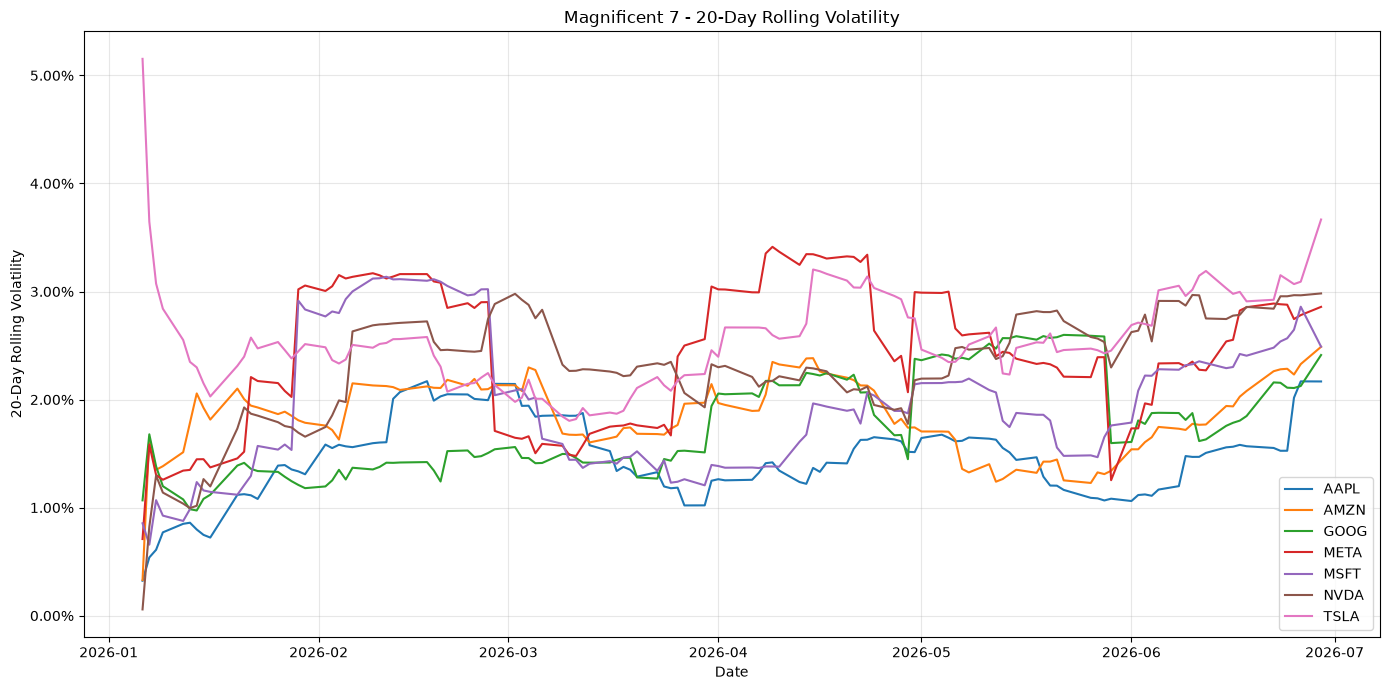

,mean,std,max
symbol,,,
AAPL,0.014544,0.003697,0.021701
AMZN,0.018421,0.003401,0.024882
GOOG,0.017640,0.004623,0.025987
META,0.024234,0.006539,0.034136
MSFT,0.019603,0.006289,0.031367
NVDA,0.023041,0.005245,0.029822
TSLA,0.025564,0.004601,0.051534


In [7]:
plt.figure(figsize=(14, 7))
for symbol, data in rolling_volatility_df.groupby("symbol"):
    plt.plot(data["trade_date"], data["rolling_20d_volatility"], label=symbol)

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

plt.title("Magnificent 7 - 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("20-Day Rolling Volatility")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rolling_volatility_df.groupby("symbol")["rolling_20d_volatility"].agg(["mean", "std", "max"])

### Key Findings

- Rolling volatility varies considerably over time, demonstrating that short-term market risk is dynamic rather than constant.
- Nvidia and Tesla generally exhibit higher rolling volatility than Apple, indicating greater short-term price fluctuations.
- Several periods of elevated volatility occur simultaneously across multiple stocks, suggesting broader market effects.
- Rolling volatility complements the daily return analysis by providing a clearer measure of short-term investement risk.

## 7. Moving Averages Analysis

### Research Question

How do the 20-day and 50-day moving averages indicate short-term market trends, and which stocks currently exhibit bullish trend signals?

In [8]:
latest_moving_average_df = (
    moving_averages_df
    .groupby("symbol")
    .last()
)

moving_average_screen_df = latest_moving_average_df[
    latest_moving_average_df["moving_20d_average"] 
    > 
    latest_moving_average_df["moving_50d_average"]
]

display(Markdown('#### Latest Moving Average Snapshot'))
display(latest_moving_average_df)

display(Markdown('#### Bullish Moving Average Snapshot'))
display(moving_average_screen_df)

#### Latest Moving Average Snapshot

,trade_date,adj_close,moving_20d_average,moving_50d_average
symbol,,,,
AAPL,2026-06-29,281.739990,296.772500,291.783297
AMZN,2026-06-29,240.139999,242.500499,255.937600
GOOG,2026-06-29,351.279999,357.395715,366.844742
META,2026-06-29,562.599976,579.523498,610.152745
MSFT,2026-06-29,368.570007,396.024496,409.506334
NVDA,2026-06-29,194.970001,206.917970,209.854869
TSLA,2026-06-29,411.839996,400.355497,405.223799


#### Bullish Moving Average Snapshot

,trade_date,adj_close,moving_20d_average,moving_50d_average
symbol,,,,
AAPL,2026-06-29,281.73999,296.7725,291.783297


#### Detailed Moving Average Analysis: AAPL

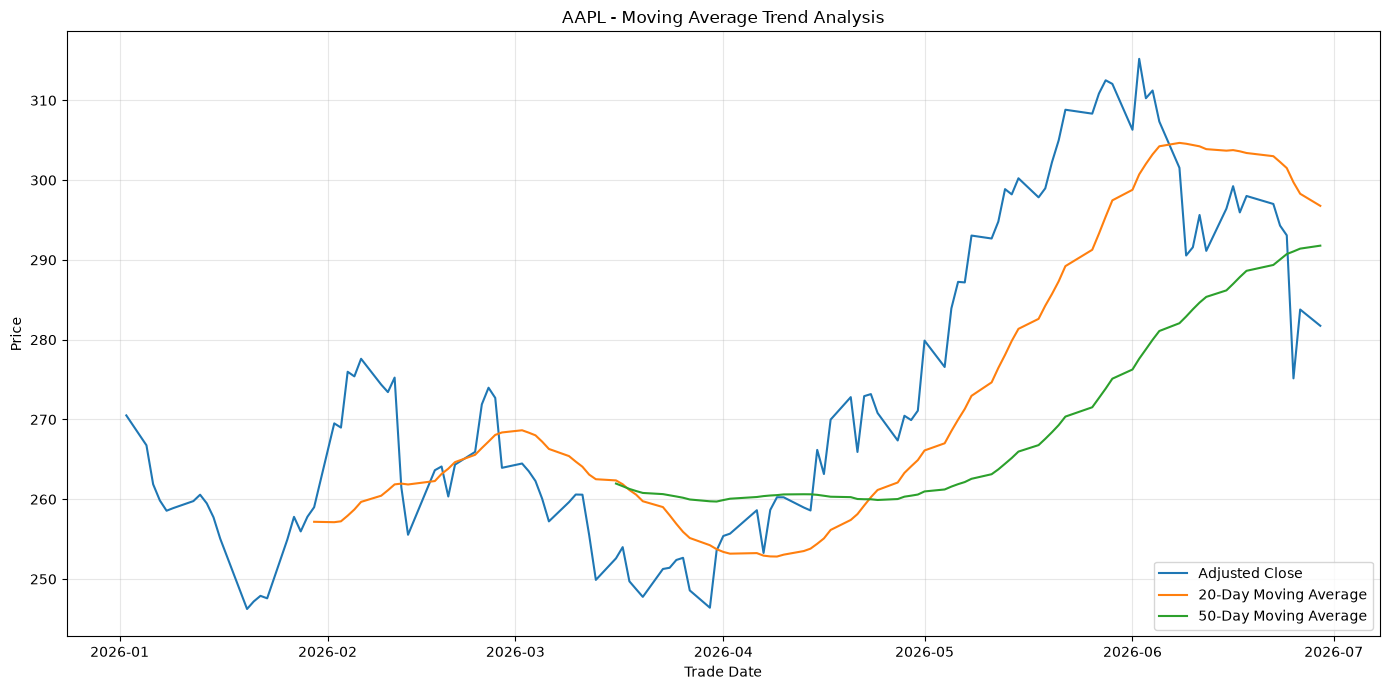

In [9]:
selected_ma_symbol = moving_average_screen_df.index[0]

selected_ma_stock_df = (
    moving_averages_df[
        moving_averages_df["symbol"] == selected_ma_symbol
        ]
        .sort_values("trade_date")
)

display(Markdown(f"#### Detailed Moving Average Analysis: {selected_ma_symbol}"))

plt.figure(figsize=(14, 7))

plt.plot(
    selected_ma_stock_df["trade_date"],
    selected_ma_stock_df["adj_close"],
    label="Adjusted Close"
)

plt.plot(
    selected_ma_stock_df["trade_date"],
    selected_ma_stock_df["moving_20d_average"],
    label="20-Day Moving Average"
)

plt.plot(
    selected_ma_stock_df["trade_date"],
    selected_ma_stock_df["moving_50d_average"],
    label="50-Day Moving Average"
)

plt.title(f"{selected_ma_symbol} - Moving Average Trend Analysis")
plt.xlabel("Trade Date")
plt.ylabel("Price")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings

- The latest moving average snapshot provides a concise overview of the currend trend for each Magnificent 7 stock.
- At the end of Q2 2026 onyl Apple exhibits a bullish signal with its 20-day moving average aboveits 50-day moving average.
- The detailed moving average chart illustrates how the relationship between short-term and long-term moving averages evolves over time.
- Combining the screening table with the historical visualization enables both rapid stock selection and deeper trend interpretation.

## 8. Momentum Analysis

### Research Question

Which stocks currently exhibit the strongest momentum based on their 20-day returns?

In [10]:
latest_momentum_df = (
    momentum_df
    .groupby("symbol")
    .last()
    .sort_values("momentum_20d", ascending=False)
)

display(Markdown('#### Momentum Analysis Magnificent 7'))
display(
    latest_momentum_df.style.format({
        "adj_close": "{:.2f}",
        "momentum_20d": "{:.2%}"
    })
)

#### Momentum Analysis Magnificent 7

,trade_date,adj_close,momentum_20d
symbol,,,
TSLA,2026-06-29,411.84,-5.50%
GOOG,2026-06-29,351.28,-6.63%
NVDA,2026-06-29,194.97,-7.55%
AAPL,2026-06-29,281.74,-9.72%
META,2026-06-29,562.60,-10.97%
AMZN,2026-06-29,240.14,-11.27%
MSFT,2026-06-29,368.57,-18.14%


#### Detailed Momentum Analysis: TSLA

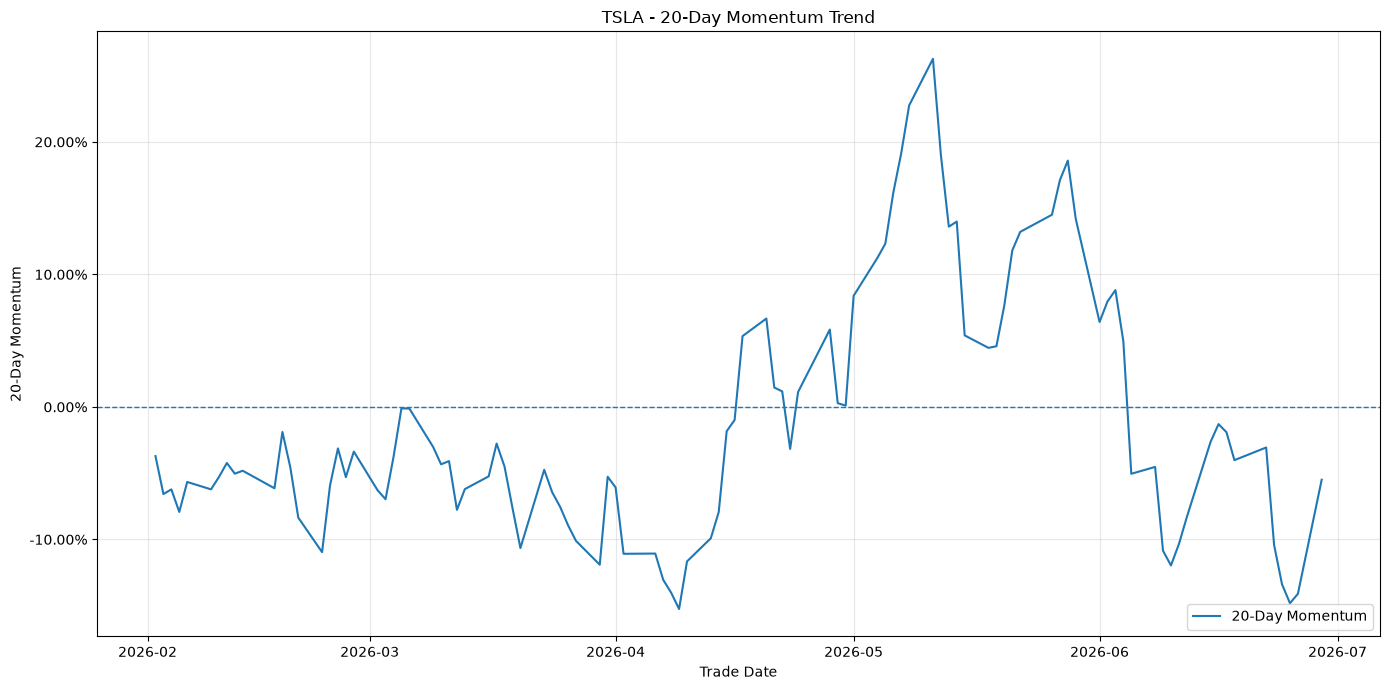

In [11]:
top_momentum_symbol = latest_momentum_df.index[0]

top_momentum_stock_df = (
    momentum_df[
        momentum_df["symbol"] == top_momentum_symbol
    ]
    .sort_values("trade_date")
)

display(Markdown(f"#### Detailed Momentum Analysis: {top_momentum_symbol}"))

plt.figure(figsize=(14, 7))

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))

plt.plot(
    top_momentum_stock_df["trade_date"],
    top_momentum_stock_df["momentum_20d"],
    label = "20-Day Momentum"
)

plt.title(f"{top_momentum_symbol} - 20-Day Momentum Trend")
plt.xlabel("Trade Date")
plt.ylabel("20-Day Momentum")
plt.axhline(y=0, linewidth=1, linestyle="--")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings

- None of the Magnificent 7 stocks exhibit positive 20-day momentum at the end of Q2 2026, indicating a broadly weaker short-term market environment.
- Tesla  ranks first in the momentum screening, although its latest 20-day momentum remains slightly negative relative to the other stocks.
- The historical momentum series demonstrates how rapidly momentum can shift between positive and negative territory, highlighting its dynamic nature.
- Combining the momentum ranking with the historical time series provides both a current market snapshot and the context required to interpret recent price performance.

## 9. Data Quality Analysis

### Research Question

Does the pipeline produce reliable and internally consistent market data suitable for quantitative analysis?

In [12]:
quality_summary = {
    "Price Validation": (
        data_quality_df["valid_price_values"] == 0
    ).sum(),
    "Volume Validation": (
        data_quality_df["valid_volume"] == 0
    ).sum(),
    "High/Low Validation": (
        data_quality_df["valid_high_low"] == 0
    ).sum(),
    "Open Range Validation": (
        data_quality_df["valid_open_range"] == 0
    ).sum(),
    "Close Range Validation": (
        data_quality_df["valid_close_range"] == 0
    ).sum(),
    "Large Daily Moves": (
        data_quality_df["large_daily_move_flag"] == 1
    ).sum()
}

quality_summary_df = pd.DataFrame(
    quality_summary.items(),
    columns=["Quality Check", "Flagged Records"]
)

display(Markdown('#### Data Quality Summary'))
display(quality_summary_df)

#### Data Quality Summary

,Quality Check,Flagged Records
0,Price Validation,0
1,Volume Validation,0
2,High/Low Validation,0
3,Open Range Validation,0
4,Close Range Validation,0
5,Large Daily Moves,0


### Key Findings

- All implemented validation checks returned zero flagged records for the analysed dataset.
- Price, volume and range validation rules confirm the internal consistency of the underlying market data.
- No unusually large daily price movements exceeded the implemented quality thresholds.
- The successful validation supports the reliability of the calculated financial metrics used throughout the previous analyses.

## 10. Conclusion

This notebook demonstrated how the Financial Metrics Pipeline can be used to transform raw market data into reliable analytical views to evaluate different aspects of market behaviour for the Magnificent 7 stocks.

Starting with daily return exploration, the analysis examined short-term return distributions, rolling volatility, moving average signals, momentum rankings and the overall quality of the underlying market data. Together, these metrics provide complementary perspectives on price behaviour, market risk and trend development while illustrating how SQL-based calculations can be combined with Python for quantitative analysis.

The final data quality validation confirmed that all implemented consistency checks passed successfully, providing confidence in the reliability of the calculated financial metrics. 

The modular design of the Financial Metrics Pipeline provides a solid foundation for further quantitative research and demostrates how SQL-based data engineering and Python-based analysis can be combined within a reproducible workflow.

### Future Work

Possible extensions of this project include:

- Expanding the analysis to a broader universe of stocks and market indices.
- Extending the historical time horizon to enable long-term trend and risk-analyses.
- Utilizing the pipeline's multi-source architecture by comparing different market data providers and evaluating the impact of source prioritisation on the analytical results.
- Integrating additional technical indicators such as RSI, MACD and Bollinger Bands.
- Adding performance metrics such as cumulative returns, Sharpe Ratio and maximum drawdown.
- Automating the data ingestion process to support regularly updated analyses.